In [30]:
!pip install -q catboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [32]:
# 한글 폰트 설정
!pip install koreanize-matplotlib -q

try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
#시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [34]:
TARGET = "임신 성공 여부"
ID_COL = "ID"
DATA_DIR = Path(".")   # 데이터 경로 수정

SEED = 42

단변량 분석


  전처리 전 결측치 현황 (Train)  (결측 컬럼: 31개 / 전체: 67개)
  🔴 난자 해동 경과일                        254,915건   99.4%  float64     컬럼 제거
  🔴 PGS 시술 여부                        254,422건   99.2%  float64     컬럼 제거
  🔴 PGD 시술 여부                        254,172건   99.1%  float64     컬럼 제거
  🔴 착상 전 유전 검사 사용 여부                 253,633건   98.9%  float64     컬럼 제거
  🔴 임신 시도 또는 마지막 임신 경과 연수            246,981건   96.3%  float64     컬럼 제거
  🔴 배아 해동 경과일                        215,982건   84.3%  float64     컬럼 제거
  🟠 난자 채취 경과일                        57,488건   22.4%  float64     중앙값 대체
  🟠 난자 혼합 경과일                        53,735건   21.0%  float64     중앙값 대체
  🟡 배아 이식 경과일                        43,566건   17.0%  float64     중앙값 대체
  🟡 저장된 배아 수                          6,291건    2.5%  float64     중앙값 대체
  🟡 단일 배아 이식 여부                       6,291건    2.5%  float64     중앙값 대체
  🟡 배아 생성 주요 이유                       6,291건    2.5%  str         최빈값 대체
  🟡 착상 전 유전 진단 사용 여부                  6,291건    2.5%  float64     중앙값 대체
  🟡

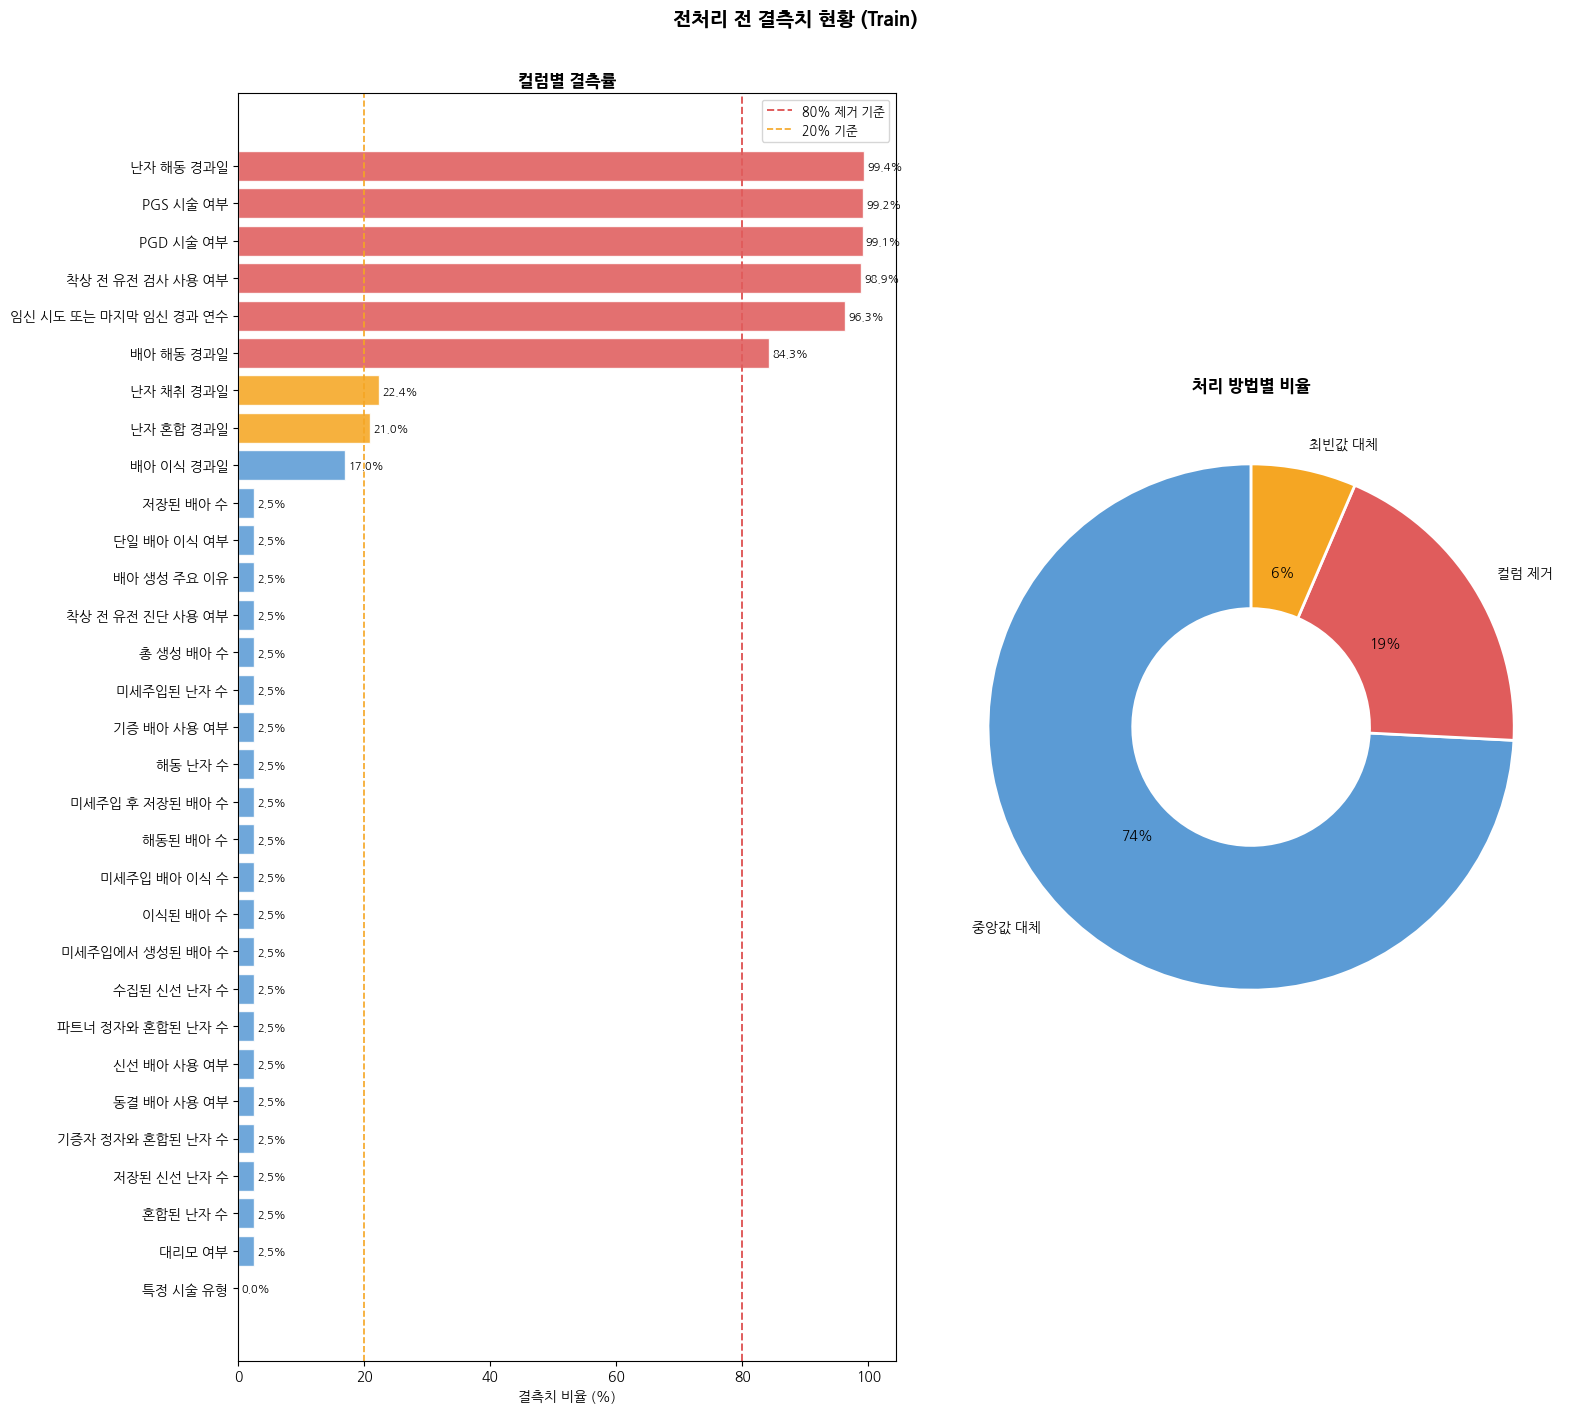

,컬럼명,결측 수,결측률(%),타입,처리 방법
0,난자 해동 경과일,254915,99.4,float64,컬럼 제거
1,PGS 시술 여부,254422,99.2,float64,컬럼 제거
2,PGD 시술 여부,254172,99.1,float64,컬럼 제거
3,착상 전 유전 검사 사용 여부,253633,98.9,float64,컬럼 제거
4,임신 시도 또는 마지막 임신 경과 연수,246981,96.3,float64,컬럼 제거
5,배아 해동 경과일,215982,84.3,float64,컬럼 제거
6,난자 채취 경과일,57488,22.4,float64,중앙값 대체
7,난자 혼합 경과일,53735,21.0,float64,중앙값 대체
8,배아 이식 경과일,43566,17.0,float64,중앙값 대체
9,저장된 배아 수,6291,2.5,float64,중앙값 대체


In [37]:
def show_missing_summary(df, title="결측치 현황"):
    missing     = df.isnull().sum()
    missing     = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)
    dtypes      = df.dtypes[missing.index].astype(str)

    def get_method(col, pct):
        if pct >= 80:
            return "컬럼 제거"
        elif col in ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"]:
            return "중앙값 대체"
        elif df[col].dtype == object:
            return "최빈값 대체"
        else:
            return "중앙값 대체" if "float" in str(df[col].dtype) else "최빈값 대체"

    methods = [get_method(col, pct) for col, pct in missing_pct.items()]

    summary = pd.DataFrame({
        "컬럼명"    : missing.index,
        "결측 수"   : missing.values,
        "결측률(%)": missing_pct.values,
        "타입"      : dtypes.values,
        "처리 방법" : methods,
    }).reset_index(drop=True)

    print(f"\n{'='*72}")
    print(f"  {title}  (결측 컬럼: {len(summary)}개 / 전체: {df.shape[1]}개)")
    print(f"{'='*72}")
    for _, row in summary.iterrows():
        flag = "🔴" if row["결측률(%)"] >= 80 else "🟠" if row["결측률(%)"] >= 20 else "🟡"
        print(f"  {flag} {row['컬럼명']:<32} {int(row['결측 수']):>6,}건  "
              f"{row['결측률(%)']:>5.1f}%  {row['타입']:<10}  {row['처리 방법']}")
    print(f"{'='*72}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(summary) * 0.45)))
    colors = ["#E05C5C" if p >= 80 else "#F5A623" if p >= 20 else "#5B9BD5"
              for p in summary["결측률(%)"]]
    axes[0].barh(summary["컬럼명"][::-1], summary["결측률(%)"][::-1],
                 color=colors[::-1], alpha=0.88, edgecolor="white")
    axes[0].axvline(80, color="#E05C5C", linestyle="--", linewidth=1.4, label="80% 제거 기준")
    axes[0].axvline(20, color="#F5A623", linestyle="--", linewidth=1.2, label="20% 기준")
    for i, val in enumerate(summary["결측률(%)"][::-1]):
        axes[0].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)
    axes[0].set_xlabel("결측치 비율 (%)")
    axes[0].set_title("컬럼별 결측률", fontweight="bold")
    axes[0].legend(fontsize=9)

    method_counts = summary["처리 방법"].value_counts()
    pie_colors = {"컬럼 제거": "#E05C5C", "중앙값 대체": "#5B9BD5", "최빈값 대체": "#F5A623"}
    axes[1].pie(
        method_counts.values, labels=method_counts.index, autopct="%1.0f%%",
        colors=[pie_colors.get(m, "#AAAAAA") for m in method_counts.index],
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.55},
    )
    axes[1].set_title("처리 방법별 비율", fontweight="bold")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


# train에서 ID, 타겟 제외하고 결측 확인
show_missing_summary(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    "전처리 전 결측치 현황 (Train)"
)


  수치형 변수 이상치 현황 (IQR 기준)
                  최솟값   Q1  중앙값    Q3   최댓값  이상치 수  이상치율(%)    하한    상한
컬럼명                                                                    
총 생성 배아 수         0.0  1.0  4.0   8.0  51.0   3312      1.3  -9.5  18.5
미세주입된 난자 수        0.0  0.0  0.0   7.0  51.0   7511      3.0 -10.5  17.5
미세주입에서 생성된 배아 수   0.0  0.0  0.0   5.0  43.0   8524      3.4  -7.5  12.5
이식된 배아 수          0.0  1.0  1.0   2.0   3.0      0      0.0  -0.5   3.5
저장된 배아 수          0.0  0.0  0.0   2.0  51.0  14218      5.7  -3.0   5.0
수집된 신선 난자 수       0.0  2.0  8.0  13.0  51.0   2733      1.1 -14.5  29.5
혼합된 난자 수          0.0  3.0  7.0  11.0  51.0   5314      2.1  -9.0  23.0
파트너 정자와 혼합된 난자 수  0.0  0.0  6.0  11.0  51.0   2035      0.8 -16.5  27.5
배아 이식 경과일         0.0  2.0  3.0   5.0   7.0      0      0.0  -2.5   9.5
난자 혼합 경과일         0.0  0.0  0.0   0.0   7.0    696      0.3   0.0   0.0


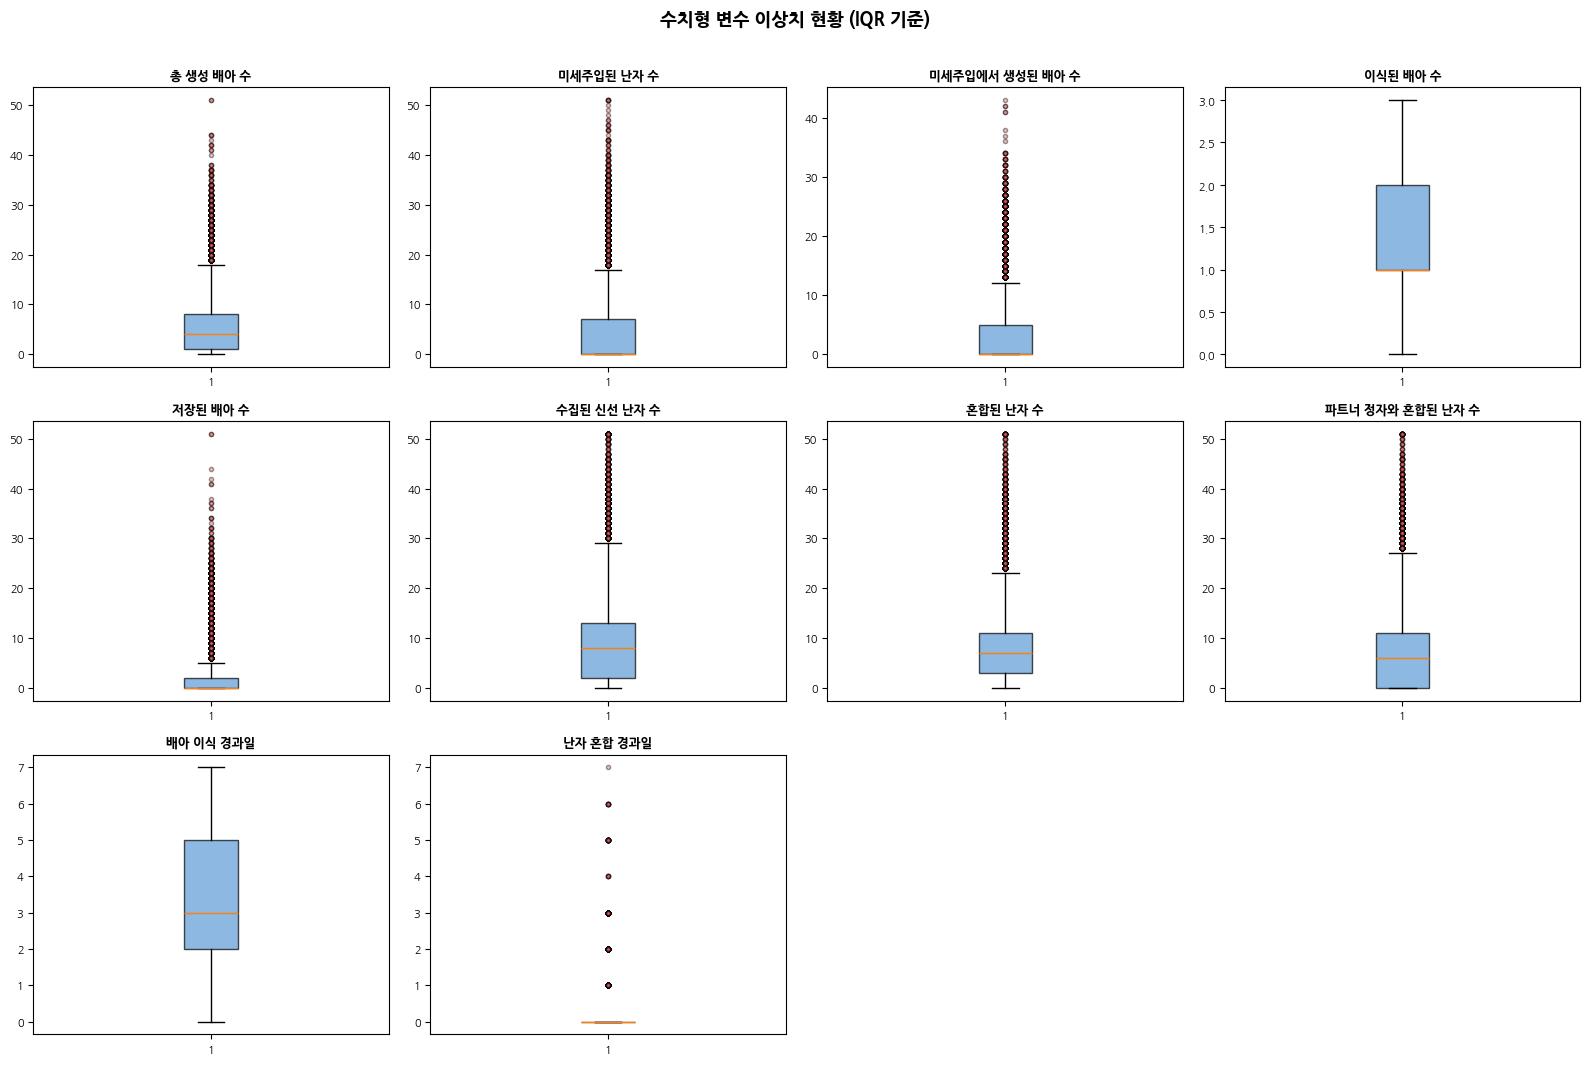

,컬럼명,최솟값,Q1,중앙값,Q3,최댓값,이상치 수,이상치율(%),하한,상한
0,총 생성 배아 수,0.0,1.0,4.0,8.0,51.0,3312,1.3,-9.5,18.5
1,미세주입된 난자 수,0.0,0.0,0.0,7.0,51.0,7511,3.0,-10.5,17.5
2,미세주입에서 생성된 배아 수,0.0,0.0,0.0,5.0,43.0,8524,3.4,-7.5,12.5
3,이식된 배아 수,0.0,1.0,1.0,2.0,3.0,0,0.0,-0.5,3.5
4,저장된 배아 수,0.0,0.0,0.0,2.0,51.0,14218,5.7,-3.0,5.0
5,수집된 신선 난자 수,0.0,2.0,8.0,13.0,51.0,2733,1.1,-14.5,29.5
6,혼합된 난자 수,0.0,3.0,7.0,11.0,51.0,5314,2.1,-9.0,23.0
7,파트너 정자와 혼합된 난자 수,0.0,0.0,6.0,11.0,51.0,2035,0.8,-16.5,27.5
8,배아 이식 경과일,0.0,2.0,3.0,5.0,7.0,0,0.0,-2.5,9.5
9,난자 혼합 경과일,0.0,0.0,0.0,0.0,7.0,696,0.3,0.0,0.0


In [38]:
def check_outliers(df, cols, title="이상치 현황 (IQR 기준)"):
    records = []
    for col in cols:
        if col not in df.columns:
            continue
        d = df[col].dropna()
        Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_cnt = ((d < lower) | (d > upper)).sum()
        records.append({
            "컬럼명"    : col,
            "최솟값"    : d.min(),  "Q1": Q1, "중앙값": d.median(),
            "Q3"        : Q3,       "최댓값": d.max(),
            "이상치 수" : out_cnt,
            "이상치율(%)": round(out_cnt / len(d) * 100, 1),
            "하한"      : round(lower, 1), "상한": round(upper, 1),
        })

    summary = pd.DataFrame(records)
    print(f"\n{'='*72}\n  {title}\n{'='*72}")
    print(summary.set_index("컬럼명").to_string())

    n_cols = 4
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()
    valid_cols = [c for c in cols if c in df.columns]
    for i, col in enumerate(valid_cols):
        data = df[col].dropna()
        bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                             flierprops=dict(marker="o", markersize=3,
                                             markerfacecolor="#E05C5C", alpha=0.4))
        bp["boxes"][0].set_facecolor("#5B9BD5")
        bp["boxes"][0].set_alpha(0.7)
        axes[i].set_title(col, fontsize=9, fontweight="bold")
        axes[i].tick_params(labelsize=8)
    for j in range(len(valid_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    return summary


NUM_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "이식된 배아 수", "저장된 배아 수", "수집된 신선 난자 수",
    "혼합된 난자 수", "파트너 정자와 혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
]
check_outliers(
    train.drop(columns=[ID_COL, TARGET], errors="ignore"),
    NUM_COLS, "수치형 변수 이상치 현황 (IQR 기준)"
)


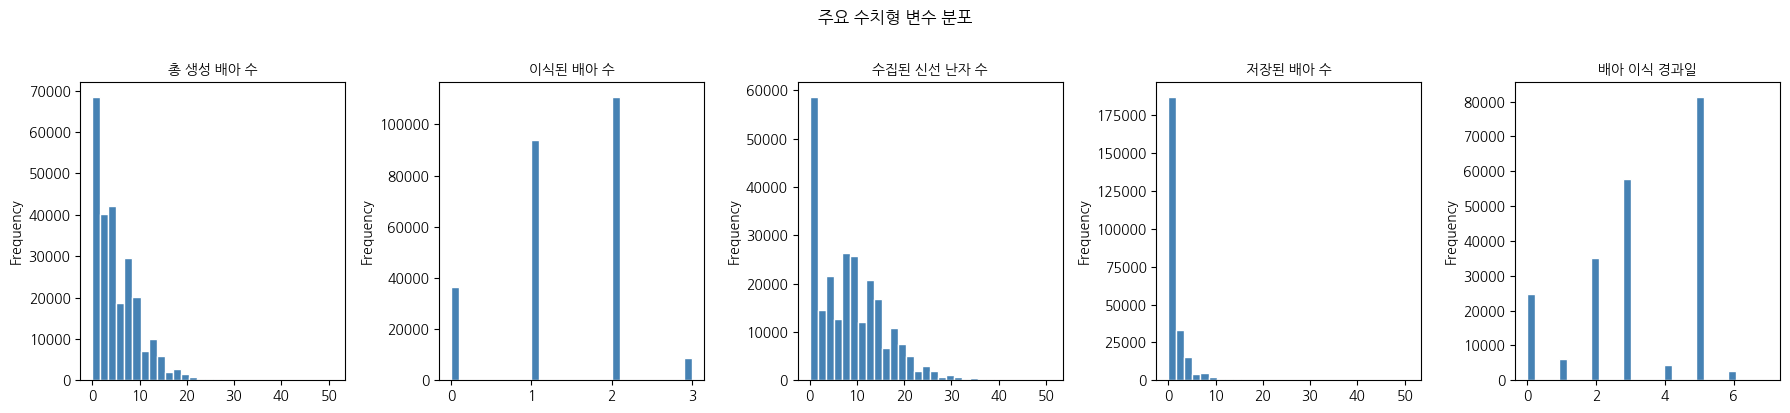

In [39]:
num_cols_view = ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
                 "저장된 배아 수", "배아 이식 경과일"]
fig, axes = plt.subplots(1, len(num_cols_view), figsize=(18, 4))
for ax, col in zip(axes, num_cols_view):
    train[col].dropna().plot(kind="hist", bins=30, ax=ax,
                             color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.suptitle("주요 수치형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

이변량 분석


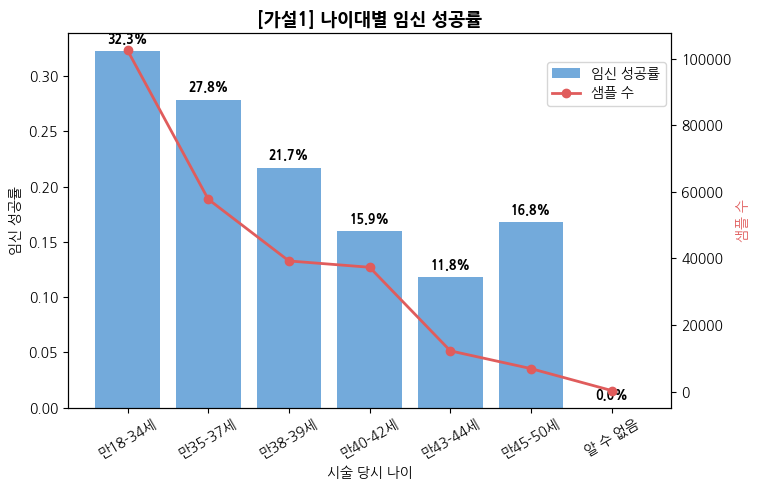

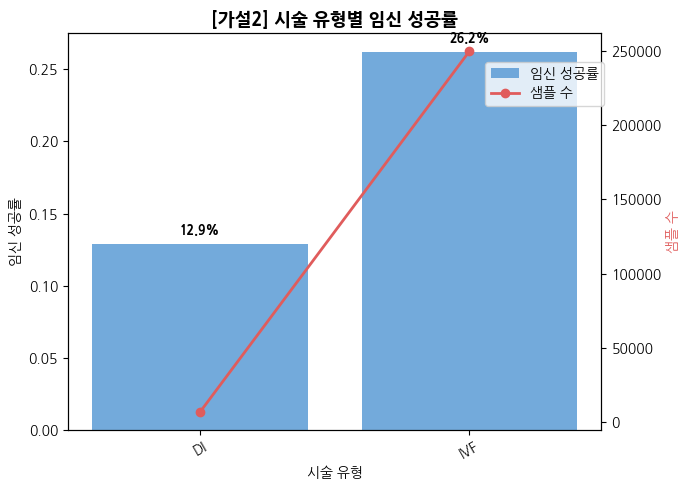

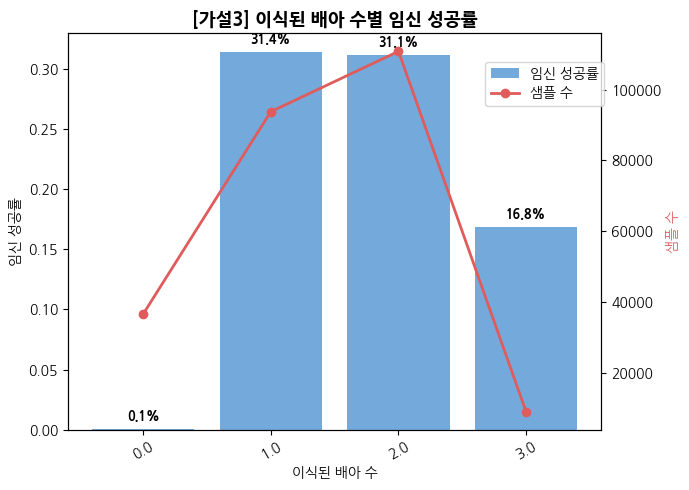

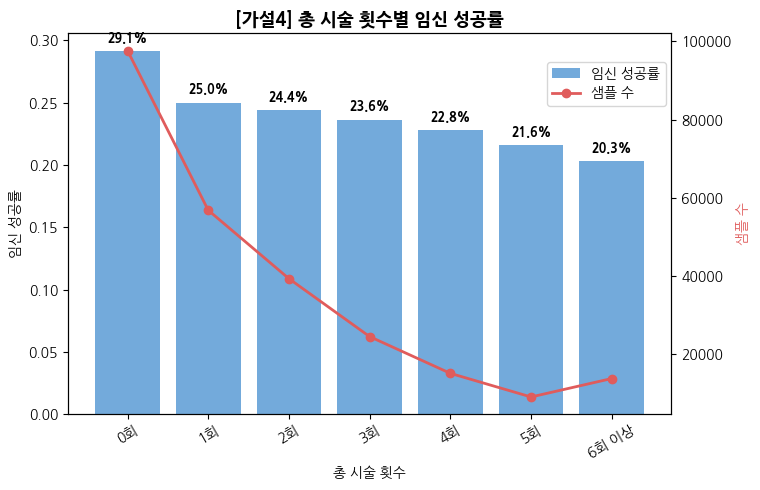

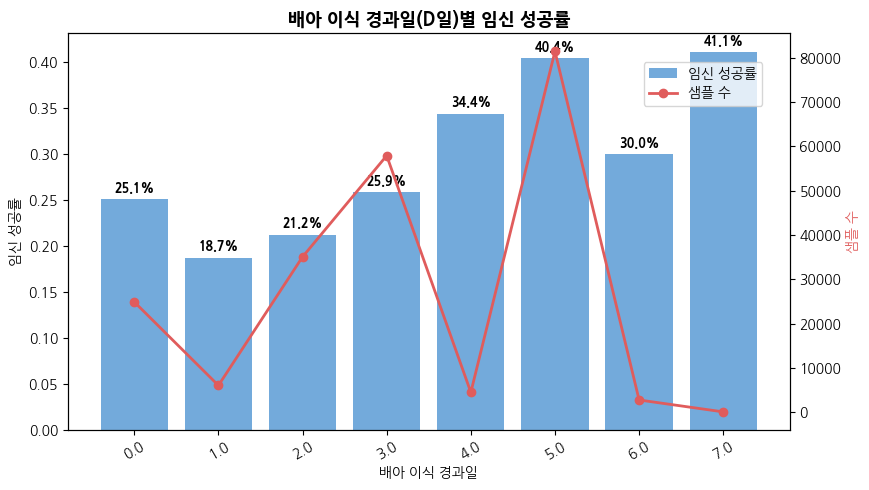

In [45]:
def plot_cat_vs_target(df, col, target, title=None, order=None):
    if col not in df.columns:
        print(f"  컬럼 없음: {col}")
        return
    grp = df.groupby(col)[target].agg(success_rate="mean", count="count").reset_index()
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)

    fig, ax1 = plt.subplots(figsize=(max(7, len(grp) * 1.1), 5))
    ax2 = ax1.twinx()
    bars = ax1.bar(grp[col].astype(str), grp["success_rate"], color="#5B9BD5", alpha=0.85, label="임신 성공률")
    ax2.plot(grp[col].astype(str), grp["count"], color="#E05C5C", marker="o", linewidth=2, label="샘플 수")
    for bar, row in zip(bars, grp.itertuples()):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{row.success_rate:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax1.set_ylabel("임신 성공률"); ax2.set_ylabel("샘플 수", color="#E05C5C")
    ax1.set_xlabel(col); ax1.tick_params(axis="x", rotation=30)
    plt.title(title or f"{col}별 임신 성공률", fontsize=13, fontweight="bold")
    fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout(); plt.show()


# 가설 1: 나이대별 성공률
plot_cat_vs_target(df, "시술 당시 나이", TARGET, "[가설1] 나이대별 임신 성공률", AGE_ORDER)

# 가설 2: 시술 유형별 성공률
plot_cat_vs_target(df, "시술 유형", TARGET, "[가설2] 시술 유형별 임신 성공률")

# 가설 3: 이식 배아 수별 성공률
plot_cat_vs_target(df, "이식된 배아 수", TARGET, "[가설3] 이식된 배아 수별 임신 성공률")

# 가설 4: 총 시술 횟수별 성공률
plot_cat_vs_target(df, "총 시술 횟수", TARGET, "[가설4] 총 시술 횟수별 임신 성공률", COUNT_ORDER)

# 배아 이식 경과일(D일)별 성공률
plot_cat_vs_target(df, "배아 이식 경과일", TARGET, "배아 이식 경과일(D일)별 임신 성공률")

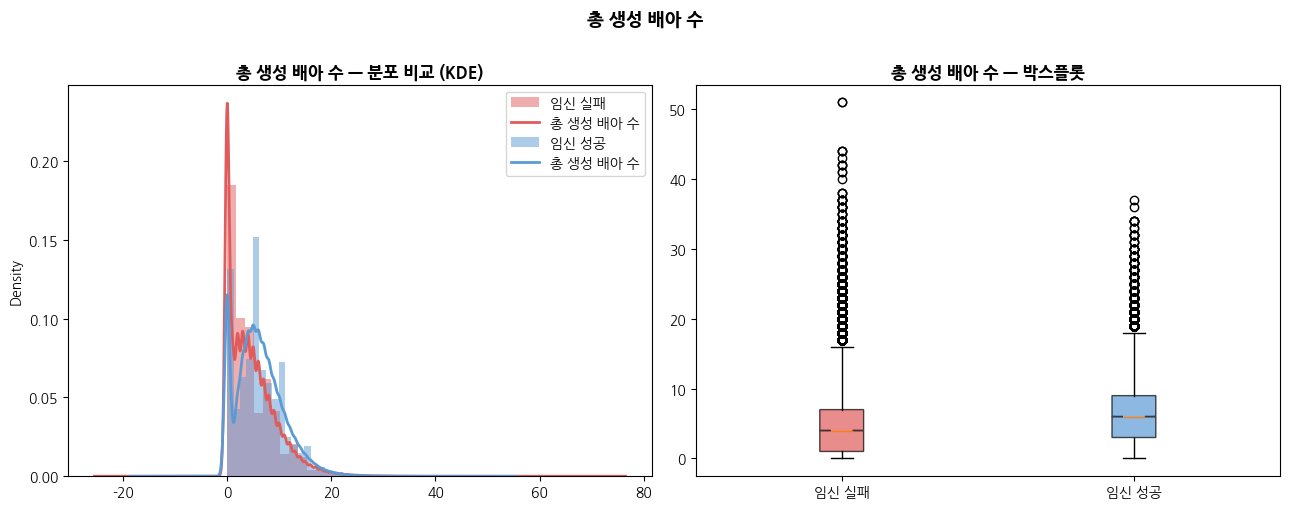

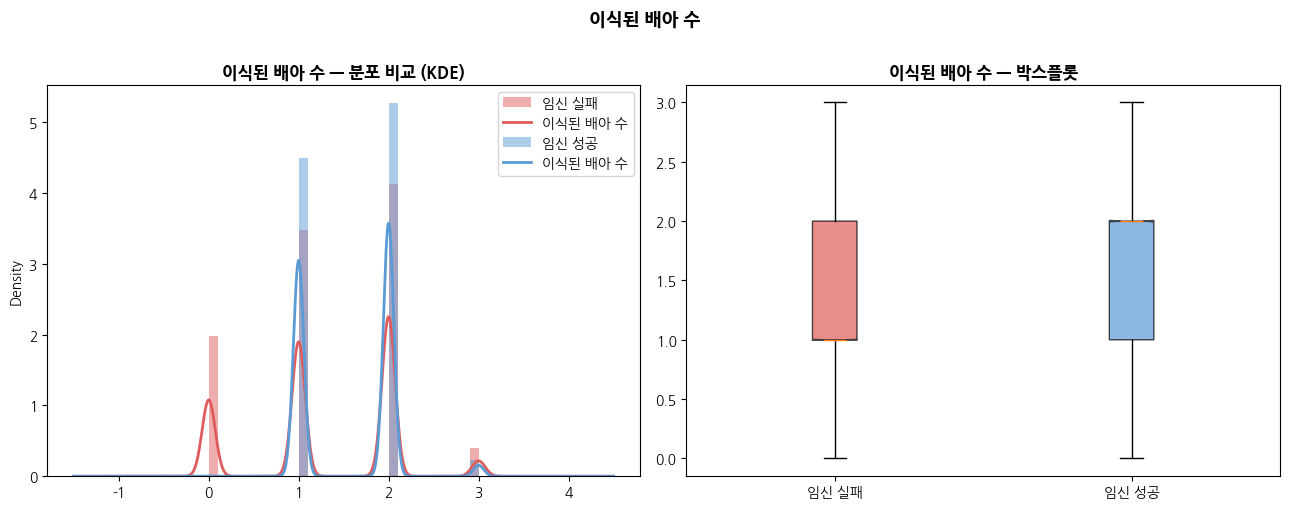

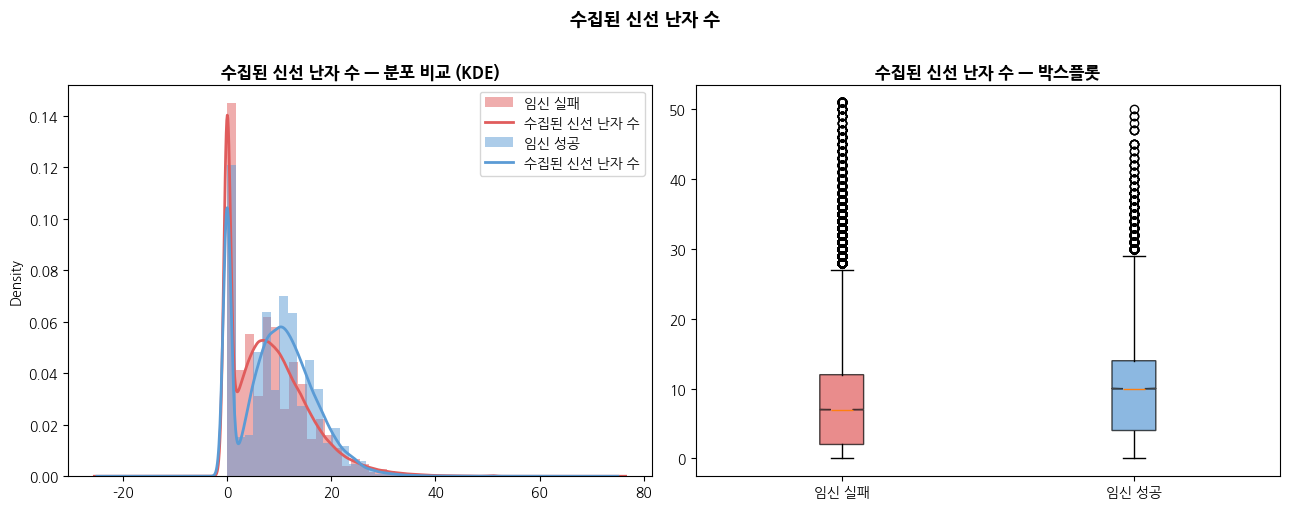

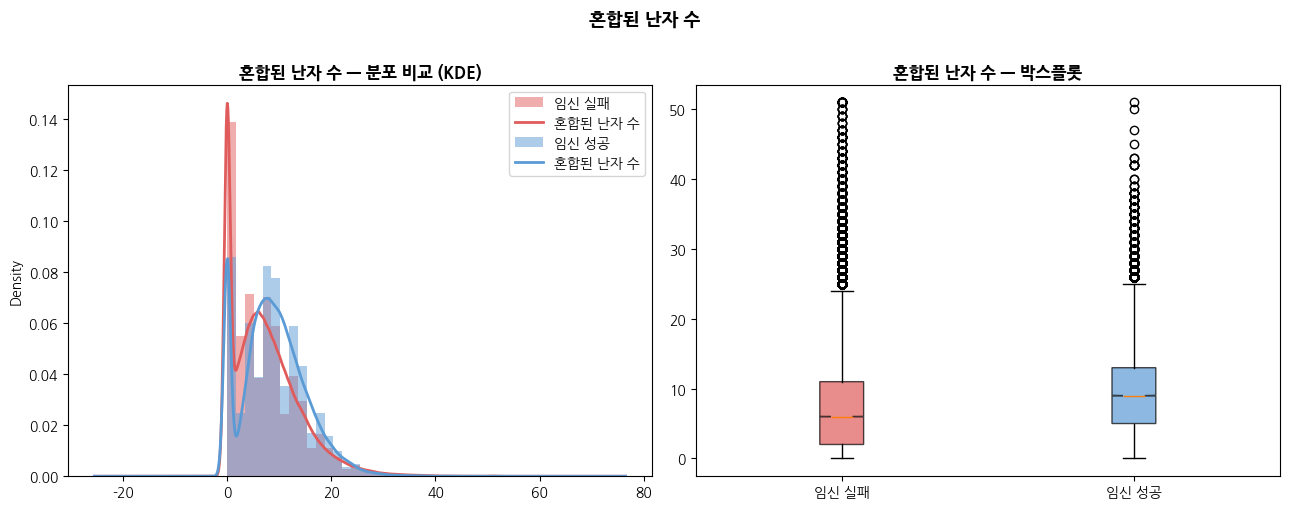

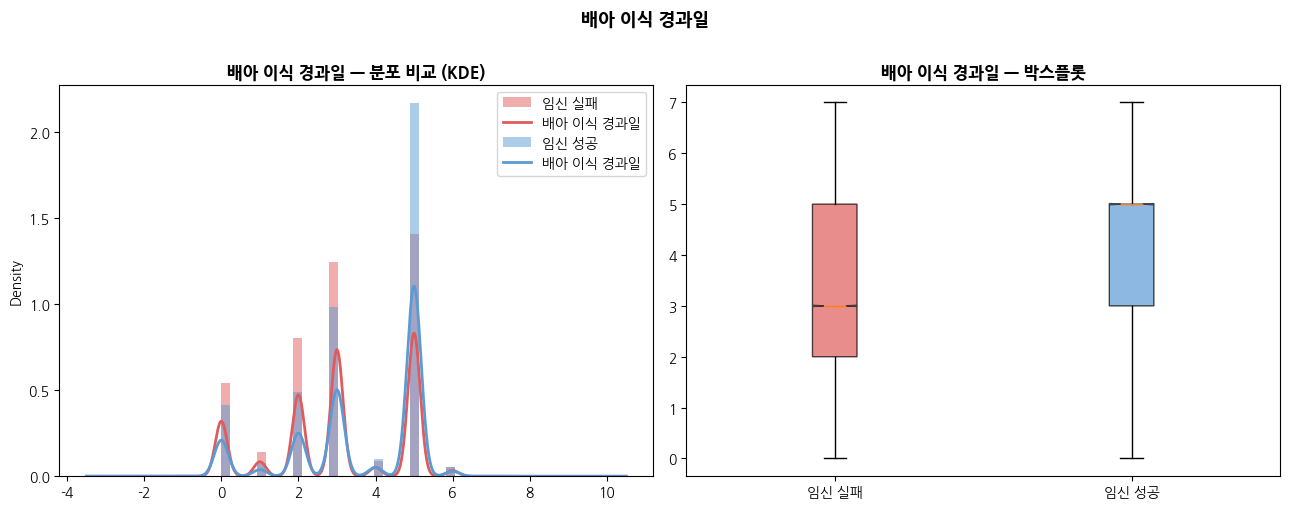

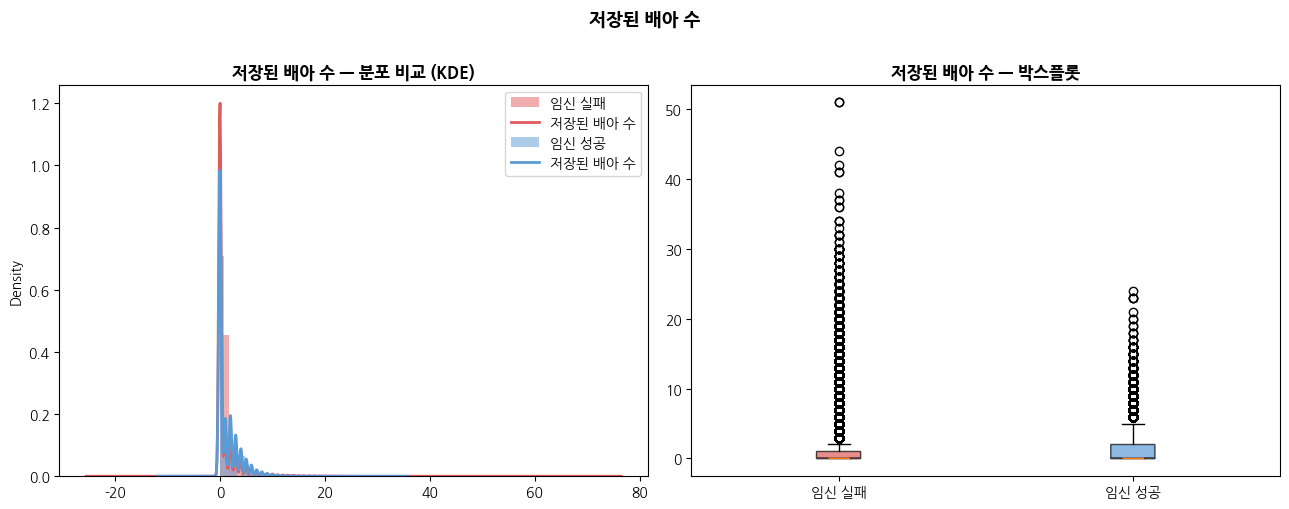

In [46]:
def plot_num_vs_target(df, col, target, title=None):
    if col not in df.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for val, label, color in [(0, "임신 실패", "#E05C5C"), (1, "임신 성공", "#5B9BD5")]:
        subset = df.loc[df[target] == val, col].dropna()
        axes[0].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[0], color=color, linewidth=2)
    axes[0].set_title(f"{col} — 분포 비교 (KDE)", fontweight="bold")
    axes[0].legend()

    bp_data = [df.loc[df[target] == 0, col].dropna(), df.loc[df[target] == 1, col].dropna()]
    bp = axes[1].boxplot(bp_data, labels=["임신 실패", "임신 성공"], patch_artist=True, notch=True)
    for patch, color in zip(bp["boxes"], ["#E05C5C", "#5B9BD5"]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_title(f"{col} — 박스플롯", fontweight="bold")
    plt.suptitle(title or col, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()


for col in ["총 생성 배아 수", "이식된 배아 수", "수집된 신선 난자 수",
            "혼합된 난자 수", "배아 이식 경과일", "저장된 배아 수"]:
    plot_num_vs_target(df, col, TARGET)


5. 상관관계 분석


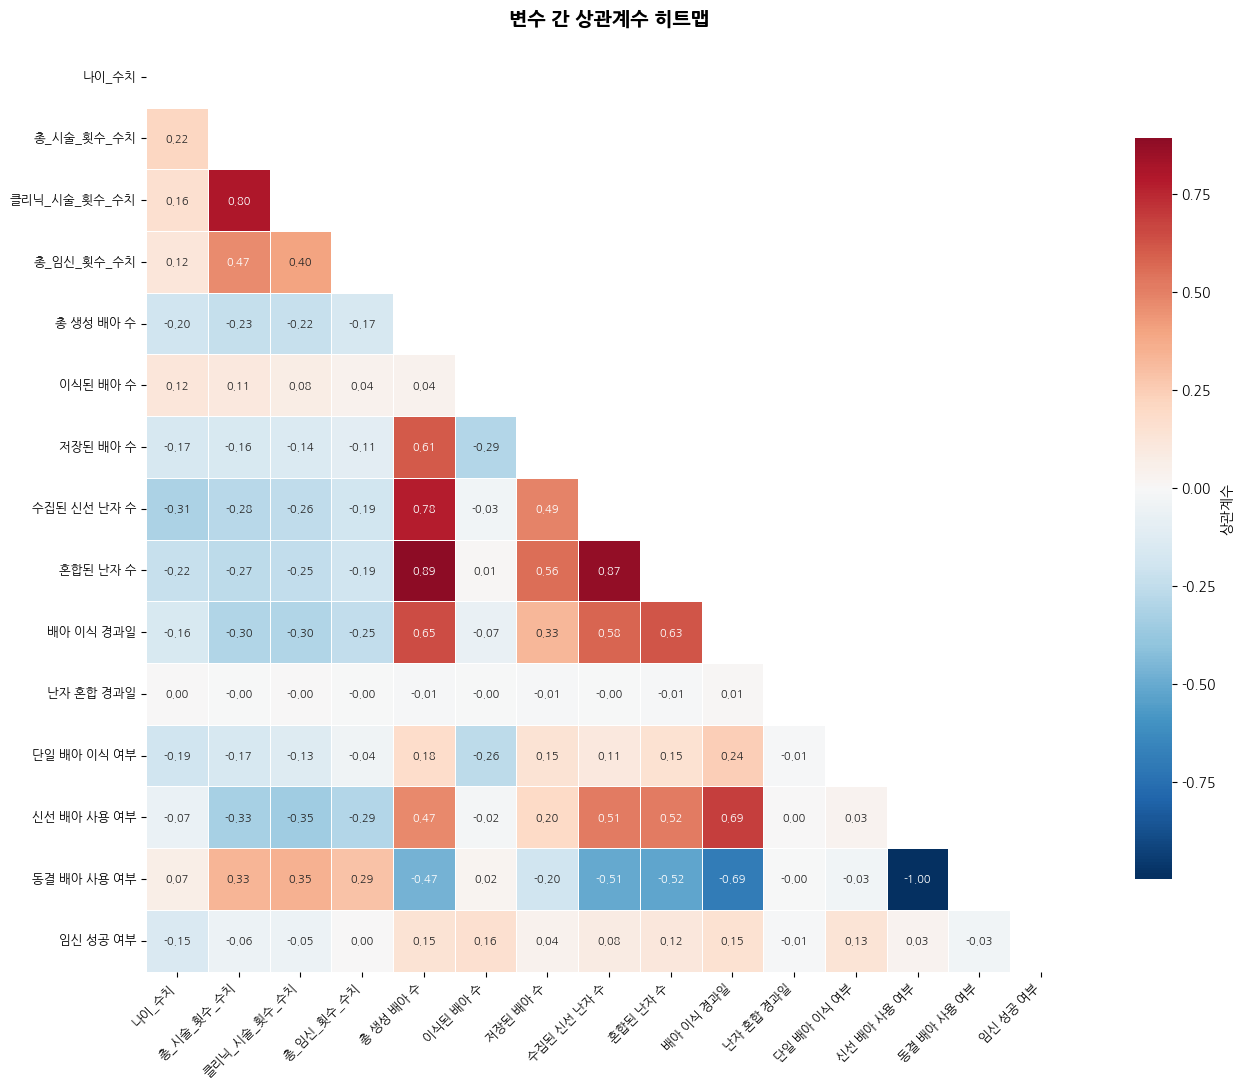

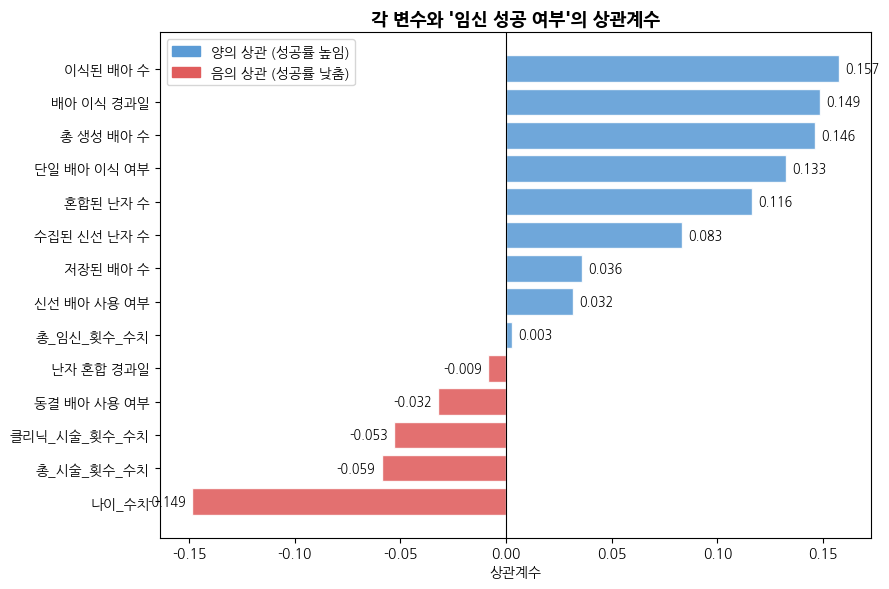


  타겟과 상관계수 TOP 10:
이식된 배아 수        0.1575
나이_수치           0.1487
배아 이식 경과일       0.1486
총 생성 배아 수       0.1461
단일 배아 이식 여부     0.1326
혼합된 난자 수        0.1161
수집된 신선 난자 수     0.0830
총_시술_횟수_수치      0.0589
클리닉_시술_횟수_수치    0.0528
저장된 배아 수        0.0360


In [47]:
print("\n" + "=" * 60)
print("5. 상관관계 분석")
print("=" * 60)

df_corr = df.copy()

# 범주형을 수치로 변환 (상관분석용)
df_corr["나이_수치"]             = df_corr["시술 당시 나이"].map(AGE_MAP)
df_corr["총_시술_횟수_수치"]     = df_corr["총 시술 횟수"].map(COUNT_MAP)
df_corr["클리닉_시술_횟수_수치"] = df_corr["클리닉 내 총 시술 횟수"].map(COUNT_MAP)
df_corr["총_임신_횟수_수치"]     = df_corr["총 임신 횟수"].map(COUNT_MAP)

CORR_COLS = [c for c in [
    "나이_수치", "총_시술_횟수_수치", "클리닉_시술_횟수_수치", "총_임신_횟수_수치",
    "총 생성 배아 수", "이식된 배아 수", "저장된 배아 수",
    "수집된 신선 난자 수", "혼합된 난자 수",
    "배아 이식 경과일", "난자 혼합 경과일",
    "단일 배아 이식 여부", "신선 배아 사용 여부", "동결 배아 사용 여부",
    TARGET,
] if c in df_corr.columns]

corr_matrix = df_corr[CORR_COLS].corr()

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, square=True,
    linewidths=0.4, cbar_kws={"label": "상관계수", "shrink": 0.8},
    annot_kws={"size": 8},
)
plt.title("변수 간 상관계수 히트맵", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

# 타겟과의 상관계수 막대그래프
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values()
colors_corr = ["#E05C5C" if v < 0 else "#5B9BD5" for v in target_corr.values]
plt.figure(figsize=(9, max(6, len(target_corr) * 0.42)))
bars = plt.barh(target_corr.index, target_corr.values, color=colors_corr, alpha=0.88, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.003 if val >= 0 else -0.003),
             bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center",
             ha="left" if val >= 0 else "right", fontsize=9)
plt.xlabel("상관계수")
plt.title(f"각 변수와 '{TARGET}'의 상관계수", fontsize=13, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#5B9BD5", label="양의 상관 (성공률 높임)"),
    mpatches.Patch(color="#E05C5C", label="음의 상관 (성공률 낮춤)"),
]
plt.legend(handles=legend_patches)
plt.tight_layout(); plt.show()

print("\n  타겟과 상관계수 TOP 10:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(4).to_string())